In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('..\\data\\datos_ventas_icsi.csv')
df

,folio,caja,usuario,dia,fecha,dia_semana,cantidad,producto,importe,valor,utilidad
0,1,Caja 1,admin,0,2024-02-21,Wednesday,1.00,Ariel Oxianillos De 500gm,28.0,25.93,2.07
1,1,Caja 1,admin,0,2024-02-21,Wednesday,1.00,Axion 720gr,29.0,23.97,5.03
2,2,Caja 1,admin,0,2024-02-21,Wednesday,1.00,Whiskas 1kg,53.0,43.79,9.21
3,3,Caja 1,admin,0,2024-02-21,Wednesday,1.00,Yomi Lala Fresa 190ml,11.0,6.50,4.50
4,4,Caja 1,admin,0,2024-02-21,Wednesday,1.00,Trikitrakes 85g,18.0,14.28,3.72
...,...,...,...,...,...,...,...,...,...,...,...
108481,72844,Caja 1,SUSANA,203,2025-07-23,Wednesday,1.00,Sardina Calmex 425g,42.0,1.46,40.54
108482,72844,Caja 1,SUSANA,203,2025-07-23,Wednesday,0.14,Queso Fresco,15.0,11.89,3.11
108483,72845,Caja 1,SUSANA,203,2025-07-23,Wednesday,1.00,Lala deslactosada 1lit,27.0,22.69,4.31
108484,72846,Caja 1,SUSANA,203,2025-07-23,Wednesday,2.00,HUEVO CRIO CONO 30PZ,172.0,161.46,10.54


# Tickets

### ¿Qué producto es el más vendido?

In [5]:
cantidad_productos = df.groupby('producto')[['cantidad', 'importe', 'utilidad']].sum()
cantidad_productos.sort_values(['cantidad', 'importe'], ascending=False).head(20)

,cantidad,importe,utilidad
producto,,,
MASTER XTREME MAYOREO RECARGA,805958.00,767287.91,17746.97
MASTERXTREME MAYOREO RECARGA,703226.50,669449.92,15449.27
MASTER TMAC MAYOREO RECARGA,314309.00,299349.82,7042.45
RECARGAS XTREME (MULTICEL-MINISUPER),297311.62,297280.49,14785.75
MASTER SERVICIOS XTREME,182769.00,182769.00,3655.38
ICSI Recargas Xtreme,141465.00,141465.00,7073.25
PAGO SERVICIOS XTREME MULTIPAGOS,118940.00,118944.01,1193.41
Abono Clientes Pay Joy,75649.00,75649.00,1512.98
ICSI Pago Servicio TMAC,36065.00,36065.00,721.30


### ¿Cuánto es el ticket promedio?

In [349]:
# Agrupar por folio
tickets = df.groupby('folio')[['importe', 'valor', 'utilidad']].sum()
# Eliminar algunos outliers
tickets = tickets[tickets['importe'] >= 1]

In [351]:
tickets.sort_values('importe', ascending=True)

,importe,valor,utilidad
folio,,,
41300,1.00,0.43,0.57
58321,1.00,0.58,0.42
64178,1.00,0.43,0.57
48919,1.00,0.94,0.06
29196,1.00,0.47,0.53
...,...,...,...
38285,3949.00,2815.00,1134.00
24791,3949.00,3374.00,575.00
69972,3953.18,3853.06,100.12


In [291]:
tickets.mode(), tickets.median()

(   importe  utilidad
 0     20.0      23.1,
 importe     33.00
 utilidad     6.63
 dtype: float64)

### Muestra una distribución

In [315]:
min_value = tickets['importe'].min()
edges = [i for i in np.arange(min_value-6, 306, 10)] +\
        [i for i in np.arange(320, 561, 20)]
edges2 = [i for i in np.arange(500, 981, 10)] +\
        [i for i in np.arange(995, 1006, 5)]

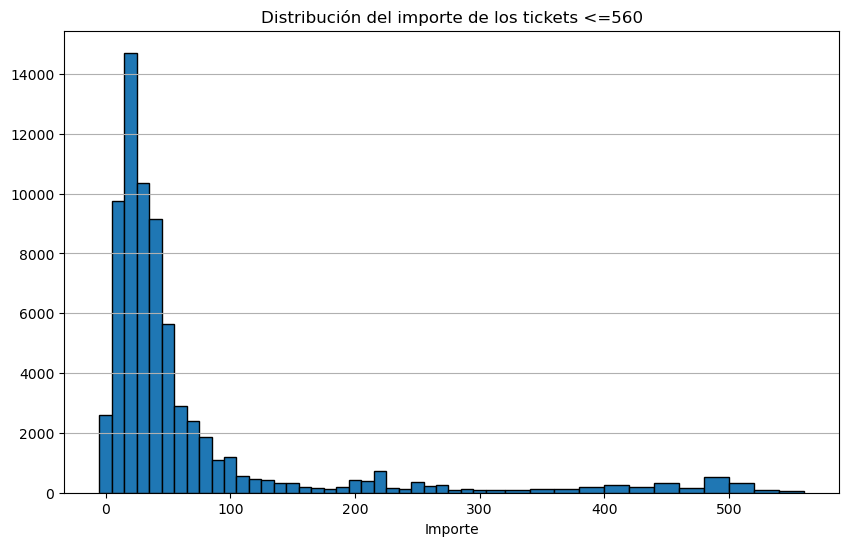

In [419]:
plt.figure(figsize=(10,6))
plt.hist(tickets['importe'], bins=edges,edgecolor='black')
plt.xlabel('Importe')
plt.title('Distribución del importe de los tickets <=560')
plt.grid(axis='y')
plt.show()

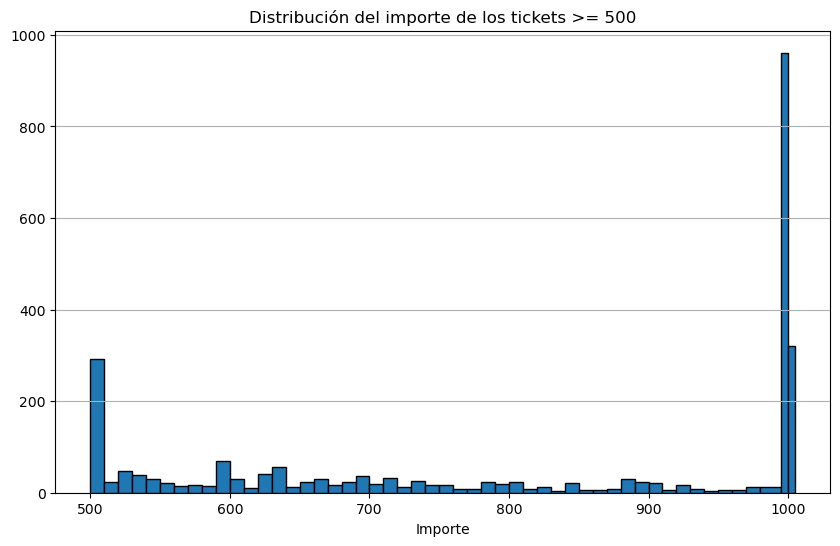

In [417]:
plt.figure(figsize=(10,6))
plt.hist(tickets['importe'], bins=edges2, edgecolor='black')
plt.xlabel('Importe')
plt.title('Distribución del importe de los tickets >= 500')
plt.grid(axis='y')
plt.show()

# ¿Cuánto se vende por día?

Vamos a volver a agrupar por tickets (folio):

In [421]:
# Agrupar por folio
tickets = df.groupby(['folio', 'dia_semana'])[['importe', 'valor', 'utilidad']].sum()
# Reindexar solo con folio
tickets = tickets.reset_index(level='dia_semana')
# Eliminar algunos outliers
tickets = tickets[tickets['importe'] >= 1]

La mediana por día:

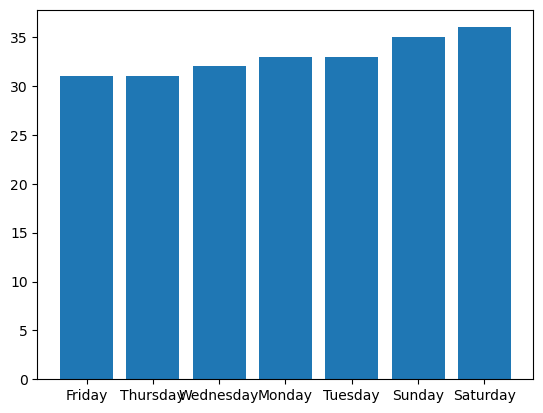

In [429]:
dias = tickets.groupby('dia_semana')[['importe']].median().sort_values('importe')
plt.bar(x=dias.index, height=dias.importe)
plt.show()

Seleccionamos por día:

In [339]:
lunes = tickets[tickets['dia_semana'] == 'Monday']
martes = tickets[tickets['dia_semana'] == 'Tuesday']
miercoles = tickets[tickets['dia_semana'] == 'Wednesday']
jueves = tickets[tickets['dia_semana'] == 'Thursday']
viernes = tickets[tickets['dia_semana'] == 'Friday']
sabado = tickets[tickets['dia_semana'] == 'Saturday']
domingo = tickets[tickets['dia_semana'] == 'Sunday']

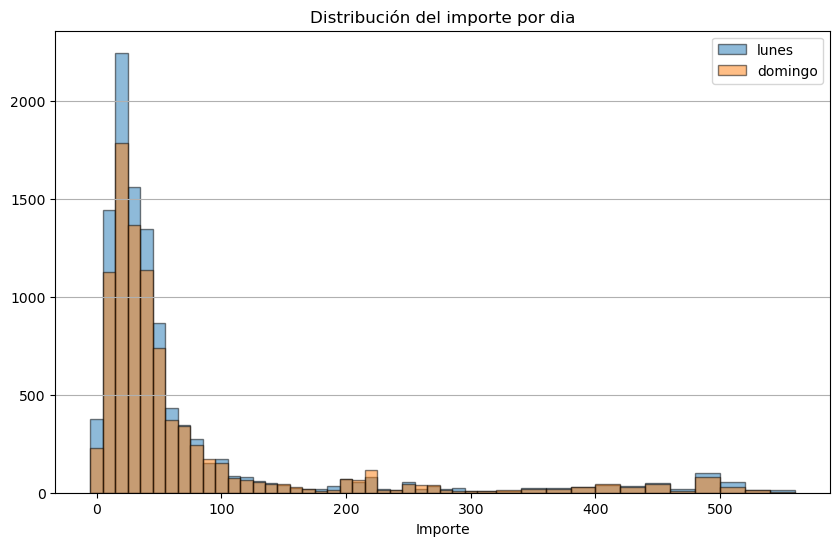

In [433]:
plt.figure(figsize=(10,6))
plt.hist(lunes['importe'], bins=edges, alpha=0.5,edgecolor='black', label='lunes')
# plt.hist(martes['importe'], bins=edges2, alpha=0.5,edgecolor='black', label='martes')
# plt.hist(miercoles['importe'], bins=edges2, alpha=0.5,edgecolor='black', label='miercoles')
# plt.hist(jueves['importe'], bins=edges2, alpha=0.5,edgecolor='black', label='jueves')
# plt.hist(viernes['importe'], bins=edges2, alpha=0.5,edgecolor='black', label='viernes')
# plt.hist(sabado['importe'], bins=edges, alpha=0.5,edgecolor='black', label='sabado')
plt.hist(domingo['importe'], bins=edges, alpha=0.5,edgecolor='black', label='domingo')
plt.legend()
plt.xlabel('Importe')
plt.title('Distribución del importe por dia')
plt.grid(axis='y')
plt.show()

## ¿Hay un patrón de productos según el día? ¿Algunos productos se compran más según el día?